<a href="https://colab.research.google.com/github/Anubhav25374/IntelliHeart-Heart-Disease-app/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn joblib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             log_loss, roc_curve)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"   Scikit-learn version : {__import__('sklearn').__version__}")
print(f"   Pandas version       : {pd.__version__}")
print(f"   Numpy version        : {np.__version__}")

✅ All libraries imported successfully!
   Scikit-learn version : 1.6.1
   Pandas version       : 2.2.2
   Numpy version        : 2.0.2


In [ ]:
from google.colab import files

print("📂 Please upload BOTH files:")
print("   1. heart.csv")
print("   2. cardio_train.csv")
print()

uploaded = files.upload()  # A file picker will appear
                            # Select BOTH files at once (hold Ctrl to select multiple)

print()
print("✅ Files uploaded!")
print("📋 Files in session:")
for filename in uploaded.keys():
    print(f"   → {filename}")

📂 Please upload BOTH files:
   1. heart.csv
   2. cardio_train.csv



Saving heart.csv to heart.csv
Saving cardio_train.csv to cardio_train.csv

✅ Files uploaded!
📋 Files in session:
   → heart.csv
   → cardio_train.csv


In [ ]:
# Load & Inspect Both Datasets
# --- Dataset 1: fedesoriano (ECG + Clinical) ---
df1 = pd.read_csv('heart.csv')

print("=" * 55)
print("📋 DATASET 1 — fedesoriano (ECG + Clinical)")
print("=" * 55)
print(f"   Rows    : {df1.shape[0]}")
print(f"   Columns : {df1.shape[1]}")
print(f"\n   Column Names:\n   {list(df1.columns)}")
print(f"\n   First 3 rows:")
display(df1.head(3))
print(f"\n   Missing Values:\n{df1.isnull().sum()}")
print(f"\n   Target Distribution:\n{df1['HeartDisease'].value_counts()}")

print()

# --- Dataset 2: Sulianova (Clinical Only) ---
df2 = pd.read_csv('cardio_train.csv', sep=';')  # This file uses semicolon separator

print("=" * 55)
print("📋 DATASET 2 — Sulianova (Clinical Only)")
print("=" * 55)
print(f"   Rows    : {df2.shape[0]}")
print(f"   Columns : {df2.shape[1]}")
print(f"\n   Column Names:\n   {list(df2.columns)}")
print(f"\n   First 3 rows:")
display(df2.head(3))
print(f"\n   Missing Values:\n{df2.isnull().sum()}")
print(f"\n   Target Distribution:\n{df2['cardio'].value_counts()}")

📋 DATASET 1 — fedesoriano (ECG + Clinical)
   Rows    : 918
   Columns : 12

   Column Names:
   ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

   First 3 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0



   Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

   Target Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

📋 DATASET 2 — Sulianova (Clinical Only)
   Rows    : 70000
   Columns : 13

   Column Names:
   ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

   First 3 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1



   Missing Values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

   Target Distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [ ]:
# Preprocessing Both Datasets
# DATASET 1 — fedesoriano (ECG + Clinical)

df1_processed = df1.copy()

# Sex: M=1, F=0
df1_processed['Sex'] = df1_processed['Sex'].map({'M': 1, 'F': 0})

# ChestPainType: ATA=0, NAP=1, ASY=2, TA=3
df1_processed['ChestPainType'] = df1_processed['ChestPainType'].map(
    {'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3})

# RestingECG: Normal=0, ST=1, LVH=2
df1_processed['RestingECG'] = df1_processed['RestingECG'].map(
    {'Normal': 0, 'ST': 1, 'LVH': 2})

# ExerciseAngina: N=0, Y=1
df1_processed['ExerciseAngina'] = df1_processed['ExerciseAngina'].map(
    {'N': 0, 'Y': 1})

# ST_Slope: Up=0, Flat=1, Down=2
df1_processed['ST_Slope'] = df1_processed['ST_Slope'].map(
    {'Up': 0, 'Flat': 1, 'Down': 2})

# Step 2: Separate Features and Target
X1 = df1_processed.drop('HeartDisease', axis=1)
y1 = df1_processed['HeartDisease']

# Step 3: Apply SMOTE to balance and increase data
smote = SMOTE(random_state=42)
X1_resampled, y1_resampled = smote.fit_resample(X1, y1)

print("=" * 55)
print("✅ DATASET 1 — Preprocessing Done")
print("=" * 55)
print(f"   Original rows  : {X1.shape[0]}")
print(f"   After SMOTE    : {X1_resampled.shape[0]}")
print(f"   Features       : {list(X1.columns)}")
print(f"\n   Target after SMOTE:\n   {pd.Series(y1_resampled).value_counts().to_dict()}")

# Step 4: Scale features
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1_resampled)

print(f"\n   ✅ Feature Scaling Done")

# -------------------------------------------------------
# DATASET 2 — Sulianova (Clinical Only)

df2_processed = df2.copy()

# Step 1: Drop ID column (not useful)
df2_processed = df2_processed.drop('id', axis=1)

# Step 2: Convert age from days to years
df2_processed['age'] = (df2_processed['age'] / 365).round(0).astype(int)

# Step 3: Remove clearly wrong/outlier values
# Blood pressure cant be negative or extremely high
df2_processed = df2_processed[
    (df2_processed['ap_hi'] >= 80) & (df2_processed['ap_hi'] <= 250) &
    (df2_processed['ap_lo'] >= 40) & (df2_processed['ap_lo'] <= 200) &
    (df2_processed['height'] >= 100) & (df2_processed['height'] <= 250) &
    (df2_processed['weight'] >= 30) & (df2_processed['weight'] <= 250)
]

# Step 4: Separate Features and Target
X2 = df2_processed.drop('cardio', axis=1)
y2 = df2_processed['cardio']

# Step 5: Scale features
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

print()
print("=" * 55)
print("✅ DATASET 2 — Preprocessing Done")
print("=" * 55)
print(f"   Original rows  : {df2.shape[0]}")
print(f"   After cleaning : {df2_processed.shape[0]}")
print(f"   Features       : {list(X2.columns)}")
print(f"\n   Target Distribution:\n   {pd.Series(y2).value_counts().to_dict()}")
print(f"\n   ✅ Feature Scaling Done")

print()
print("=" * 55)
print("🎯 Both Datasets Ready for Training!")
print("=" * 55)

✅ DATASET 1 — Preprocessing Done
   Original rows  : 918
   After SMOTE    : 1016
   Features       : ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

   Target after SMOTE:
   {0: 508, 1: 508}

   ✅ Feature Scaling Done

✅ DATASET 2 — Preprocessing Done
   Original rows  : 70000
   After cleaning : 68726
   Features       : ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

   Target Distribution:
   {0: 34704, 1: 34022}

   ✅ Feature Scaling Done

🎯 Both Datasets Ready for Training!


In [ ]:
# Preprocessing Both Datasets

# DATASET 1 — fedesoriano (ECG + Clinical)

df1_processed = df1.copy()

# Step 1: Encode categorical text columns into numbers
df1_processed['Sex']            = df1_processed['Sex'].map({'M': 1, 'F': 0})
df1_processed['ChestPainType']  = df1_processed['ChestPainType'].map({'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3})
df1_processed['RestingECG']     = df1_processed['RestingECG'].map({'Normal': 0, 'ST': 1, 'LVH': 2})
df1_processed['ExerciseAngina'] = df1_processed['ExerciseAngina'].map({'N': 0, 'Y': 1})
df1_processed['ST_Slope']       = df1_processed['ST_Slope'].map({'Up': 0, 'Flat': 1, 'Down': 2})

# Step 2: Separate Features and Target
X1 = df1_processed.drop('HeartDisease', axis=1)
y1 = df1_processed['HeartDisease']

# Step 3: Apply SMOTE
smote = SMOTE(random_state=42)
X1_resampled, y1_resampled = smote.fit_resample(X1, y1)

# Step 4: Train Test Split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1_resampled, y1_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y1_resampled
)

# Step 5: Scale features
scaler1  = StandardScaler()
X1_train = scaler1.fit_transform(X1_train)
X1_test  = scaler1.transform(X1_test)
X1_scaled = scaler1.transform(X1_resampled)

print("=" * 55)
print("✅ DATASET 1 — Preprocessing Done")
print("=" * 55)
print(f"   Original rows  : {df1.shape[0]}")
print(f"   After SMOTE    : {X1_resampled.shape[0]}")
print(f"   Training rows  : {X1_train.shape[0]}")
print(f"   Testing rows   : {X1_test.shape[0]}")
print(f"   Features       : {list(X1.columns)}")


# DATASET 2 — Sulianova (Clinical Only)
df2_processed = df2.copy()

# Step 1: Drop ID column
df2_processed = df2_processed.drop('id', axis=1)

# Step 2: Convert age from days to years
df2_processed['age'] = (df2_processed['age'] / 365).round(0).astype(int)

# Step 3: Remove outliers
df2_processed = df2_processed[
    (df2_processed['ap_hi']  >= 80)  & (df2_processed['ap_hi']  <= 250) &
    (df2_processed['ap_lo']  >= 40)  & (df2_processed['ap_lo']  <= 200) &
    (df2_processed['height'] >= 100) & (df2_processed['height'] <= 250) &
    (df2_processed['weight'] >= 30)  & (df2_processed['weight'] <= 250)
]

# Step 4: Separate Features and Target
X2 = df2_processed.drop('cardio', axis=1)
y2 = df2_processed['cardio']

# Step 5: Train Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

# Step 6: Scale features
scaler2  = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test  = scaler2.transform(X2_test)
X2_scaled = scaler2.transform(X2)

print()
print("=" * 55)
print("✅ DATASET 2 — Preprocessing Done")
print("=" * 55)
print(f"   Original rows  : {df2.shape[0]}")
print(f"   After cleaning : {df2_processed.shape[0]}")
print(f"   Training rows  : {X2_train.shape[0]}")
print(f"   Testing rows   : {X2_test.shape[0]}")
print(f"   Features       : {list(X2.columns)}")

print()
print("=" * 55)
print("🎯 Both Datasets Ready for Training!")
print("=" * 55)

✅ DATASET 1 — Preprocessing Done
   Original rows  : 918
   After SMOTE    : 1016
   Training rows  : 812
   Testing rows   : 204
   Features       : ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

✅ DATASET 2 — Preprocessing Done
   Original rows  : 70000
   After cleaning : 68726
   Training rows  : 54980
   Testing rows   : 13746
   Features       : ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

🎯 Both Datasets Ready for Training!


In [ ]:
# Train Both Models with SGDClassifier

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

EPOCHS = 100

# MODEL 1 — fedesoriano (ECG + Clinical)

model1 = SGDClassifier(
    loss='log_loss',
    learning_rate='adaptive',  # Automatically reduces learning rate
    eta0=0.01,                 # Starting learning rate
    max_iter=1,
    warm_start=True,
    random_state=42,
    tol=None
)

train1_losses = []
val1_losses   = []
train1_accs   = []
val1_accs     = []

print("=" * 55)
print("🔄 Training MODEL 1 — ECG + Clinical")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    model1.fit(X1_train, y1_train)

    train_proba = model1.predict_proba(X1_train)
    val_proba   = model1.predict_proba(X1_test)

    t_loss = log_loss(y1_train, train_proba)
    v_loss = log_loss(y1_test,  val_proba)
    t_acc  = accuracy_score(y1_train, model1.predict(X1_train))
    v_acc  = accuracy_score(y1_test,  model1.predict(X1_test))

    train1_losses.append(t_loss)
    val1_losses.append(v_loss)
    train1_accs.append(t_acc)
    val1_accs.append(v_acc)

    if epoch % 10 == 0:
        print(f"   Epoch {epoch:3d}/{EPOCHS} "
              f"| Train Loss: {t_loss:.4f} "
              f"| Val Loss: {v_loss:.4f} "
              f"| Train Acc: {t_acc*100:.2f}% "
              f"| Val Acc: {v_acc*100:.2f}%")

# Final Metrics Model 1
y1_pred       = model1.predict(X1_test)
y1_pred_proba = model1.predict_proba(X1_test)
acc1          = accuracy_score(y1_test, y1_pred)
logloss1      = log_loss(y1_test, y1_pred_proba)
roc_auc1      = roc_auc_score(y1_test, y1_pred_proba[:, 1])

print(f"\n   ✅ Final Accuracy  : {acc1 * 100:.2f}%")
print(f"   ✅ Final Log Loss  : {logloss1:.4f}")
print(f"   ✅ Final ROC-AUC   : {roc_auc1:.4f}")
print(f"\n   Classification Report:")
print(classification_report(y1_test, y1_pred,
      target_names=['No Disease', 'Heart Disease']))

# -------------------------------------------------------
# MODEL 2 — Sulianova (Clinical Only)

model2 = SGDClassifier(
    loss='log_loss',
    learning_rate='adaptive',  # Automatically reduces learning rate
    eta0=0.01,                 # Starting learning rate
    max_iter=1,
    warm_start=True,
    random_state=42,
    tol=None
)

train2_losses = []
val2_losses   = []
train2_accs   = []
val2_accs     = []

print()
print("=" * 55)
print("🔄 Training MODEL 2 — Clinical Only")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    model2.fit(X2_train, y2_train)

    train_proba = model2.predict_proba(X2_train)
    val_proba   = model2.predict_proba(X2_test)

    t_loss = log_loss(y2_train, train_proba)
    v_loss = log_loss(y2_test,  val_proba)
    t_acc  = accuracy_score(y2_train, model2.predict(X2_train))
    v_acc  = accuracy_score(y2_test,  model2.predict(X2_test))

    train2_losses.append(t_loss)
    val2_losses.append(v_loss)
    train2_accs.append(t_acc)
    val2_accs.append(v_acc)

    if epoch % 10 == 0:
        print(f"   Epoch {epoch:3d}/{EPOCHS} "
              f"| Train Loss: {t_loss:.4f} "
              f"| Val Loss: {v_loss:.4f} "
              f"| Train Acc: {t_acc*100:.2f}% "
              f"| Val Acc: {v_acc*100:.2f}%")

# Final Metrics Model 2
y2_pred       = model2.predict(X2_test)
y2_pred_proba = model2.predict_proba(X2_test)
acc2          = accuracy_score(y2_test, y2_pred)
logloss2      = log_loss(y2_test, y2_pred_proba)
roc_auc2      = roc_auc_score(y2_test, y2_pred_proba[:, 1])

print(f"\n   ✅ Final Accuracy  : {acc2 * 100:.2f}%")
print(f"   ✅ Final Log Loss  : {logloss2:.4f}")
print(f"   ✅ Final ROC-AUC   : {roc_auc2:.4f}")
print(f"\n   Classification Report:")
print(classification_report(y2_test, y2_pred,
      target_names=['No Disease', 'Heart Disease']))

print()
print("=" * 55)
print("🎯 Both Models Trained Successfully!")
print("=" * 55)

🔄 Training MODEL 1 — ECG + Clinical
   Epoch  10/100 | Train Loss: 0.3398 | Val Loss: 0.3672 | Train Acc: 87.32% | Val Acc: 87.25%
   Epoch  20/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%
   Epoch  30/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%
   Epoch  40/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%
   Epoch  50/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%
   Epoch  60/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%
   Epoch  70/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%
   Epoch  80/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%
   Epoch  90/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%
   Epoch 100/100 | Train Loss: 0.3399 | Val Loss: 0.3677 | Train Acc: 87.44% | Val Acc: 87.25%

   ✅ Final Ac

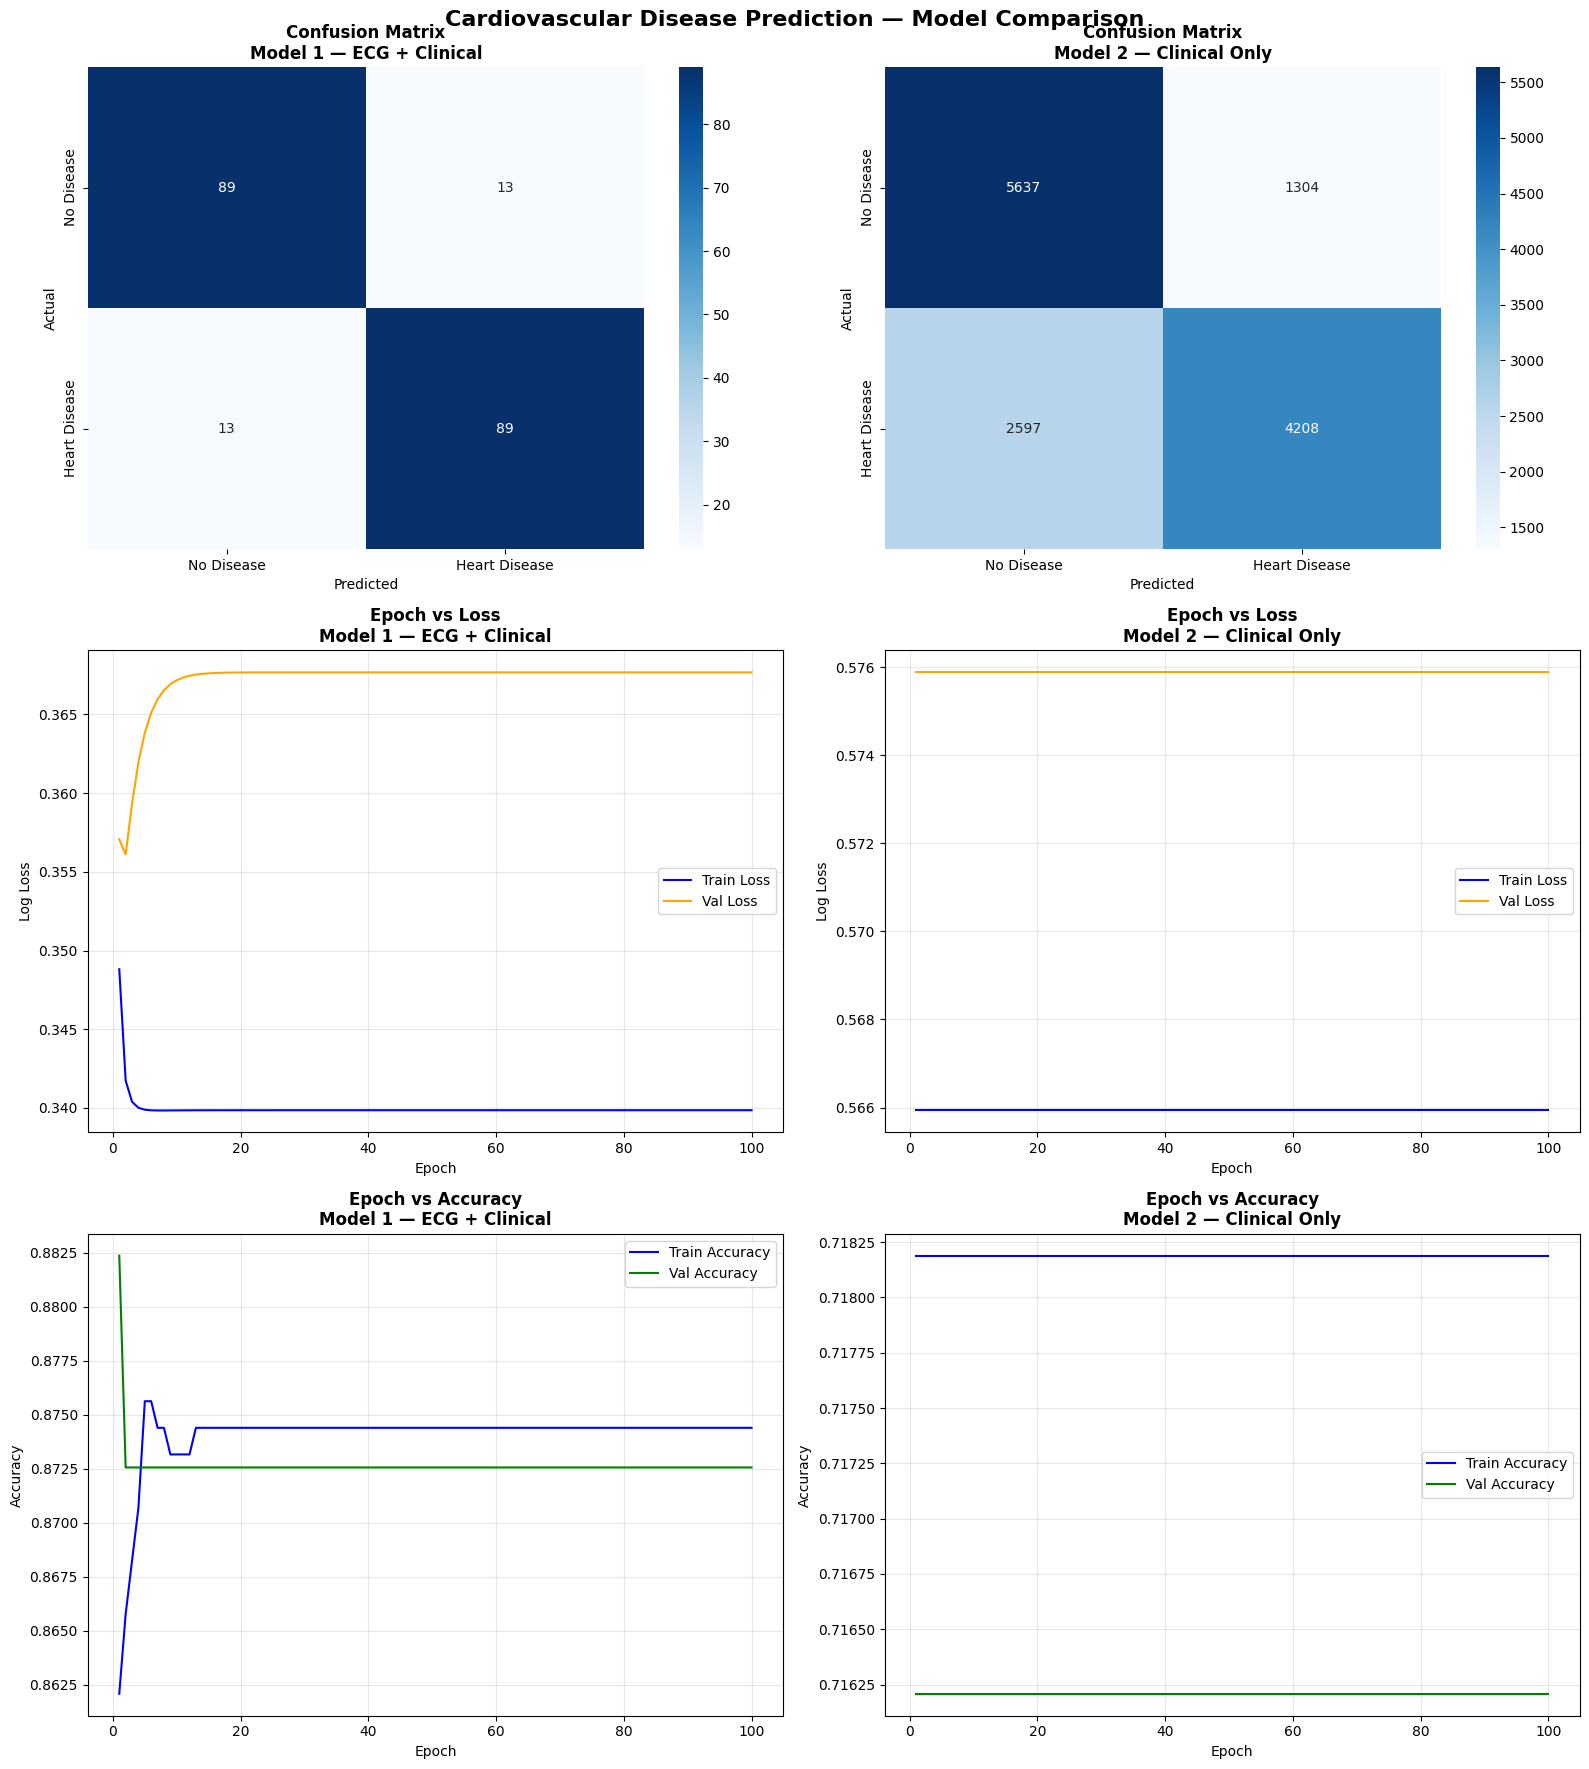

✅ All plots saved and displayed!


In [ ]:
# Visualizations for Both Models

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Cardiovascular Disease Prediction — Model Comparison',
             fontsize=16, fontweight='bold')

# PLOT 1 & 2 — Confusion Matrices
for idx, (y_test, y_pred, title) in enumerate([
    (y1_test, y1_pred, 'Model 1 — ECG + Clinical'),
    (y2_test, y2_pred, 'Model 2 — Clinical Only')
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                ax=axes[0][idx])
    axes[0][idx].set_title(f'Confusion Matrix\n{title}', fontweight='bold')
    axes[0][idx].set_ylabel('Actual')
    axes[0][idx].set_xlabel('Predicted')

# PLOT 3 & 4 — Epoch vs Loss Curves
for idx, (t_losses, v_losses, title) in enumerate([
    (train1_losses, val1_losses, 'Model 1 — ECG + Clinical'),
    (train2_losses, val2_losses, 'Model 2 — Clinical Only')
]):
    axes[1][idx].plot(range(1, EPOCHS + 1), t_losses,
                      color='blue', label='Train Loss')
    axes[1][idx].plot(range(1, EPOCHS + 1), v_losses,
                      color='orange', label='Val Loss')
    axes[1][idx].set_xlabel('Epoch')
    axes[1][idx].set_ylabel('Log Loss')
    axes[1][idx].set_title(f'Epoch vs Loss\n{title}', fontweight='bold')
    axes[1][idx].legend()
    axes[1][idx].grid(True, alpha=0.3)

# PLOT 5 & 6 — Epoch vs Accuracy Curves
for idx, (t_accs, v_accs, title) in enumerate([
    (train1_accs, val1_accs, 'Model 1 — ECG + Clinical'),
    (train2_accs, val2_accs, 'Model 2 — Clinical Only')
]):
    axes[2][idx].plot(range(1, EPOCHS + 1), t_accs,
                      color='blue', label='Train Accuracy')
    axes[2][idx].plot(range(1, EPOCHS + 1), v_accs,
                      color='green', label='Val Accuracy')
    axes[2][idx].set_xlabel('Epoch')
    axes[2][idx].set_ylabel('Accuracy')
    axes[2][idx].set_title(f'Epoch vs Accuracy\n{title}', fontweight='bold')
    axes[2][idx].legend()
    axes[2][idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All plots saved and displayed!")

In [ ]:
# ============================================================
# PHASE 7 (FIXED): Save & Display Download Links
# ============================================================
import json
import os

# Save Model 1 (ECG + Clinical)
joblib.dump(model1,  'model1_ecg_clinical.pkl')
joblib.dump(scaler1, 'scaler1_ecg_clinical.pkl')

# Save Model 2 (Clinical Only)
joblib.dump(model2,  'model2_clinical_only.pkl')
joblib.dump(scaler2, 'scaler2_clinical_only.pkl')

# Save feature names
with open('features1.json', 'w') as f:
    json.dump(list(X1.columns), f)

with open('features2.json', 'w') as f:
    json.dump(list(X2.columns), f)

print("✅ All files saved in Colab!")
print()

# Show file sizes
files_list = [
    'model1_ecg_clinical.pkl',
    'scaler1_ecg_clinical.pkl',
    'model2_clinical_only.pkl',
    'scaler2_clinical_only.pkl',
    'features1.json',
    'features2.json'
]

print("📋 File sizes:")
for f in files_list:
    size = os.path.getsize(f)
    print(f"   ✅ {f} — {size} bytes")

print()
print("=" * 55)
print("📥 METHOD 1: Download via Left Panel")
print("=" * 55)
print("""
👉 Follow these steps:
   1. Look at the LEFT side of Colab
   2. Click the FOLDER icon (📁)
   3. You will see all files listed there
   4. Right click on 'model1_ecg_clinical.pkl'
   5. Click 'Download'
   6. Repeat for all 6 files
""")

print("=" * 55)
print("📥 METHOD 2: Download as ZIP")
print("=" * 55)

import zipfile
with zipfile.ZipFile('heart_disease_models.zip', 'w') as zipf:
    for f in files_list:
        zipf.write(f)
        print(f"   Added: {f}")

print()
print(f"   ✅ ZIP created: {os.path.getsize('heart_disease_models.zip')} bytes")
print()
print("👉 In the LEFT panel folder icon:")
print("   Find 'heart_disease_models.zip'")
print("   Right click → Download")

✅ All files saved in Colab!

📋 File sizes:
   ✅ model1_ecg_clinical.pkl — 1175 bytes
   ✅ scaler1_ecg_clinical.pkl — 1231 bytes
   ✅ model2_clinical_only.pkl — 1175 bytes
   ✅ scaler2_clinical_only.pkl — 1215 bytes
   ✅ features1.json — 136 bytes
   ✅ features2.json — 105 bytes

📥 METHOD 1: Download via Left Panel

👉 Follow these steps:
   1. Look at the LEFT side of Colab
   2. Click the FOLDER icon (📁)
   3. You will see all files listed there
   4. Right click on 'model1_ecg_clinical.pkl'
   5. Click 'Download'
   6. Repeat for all 6 files

📥 METHOD 2: Download as ZIP
   Added: model1_ecg_clinical.pkl
   Added: scaler1_ecg_clinical.pkl
   Added: model2_clinical_only.pkl
   Added: scaler2_clinical_only.pkl
   Added: features1.json
   Added: features2.json

   ✅ ZIP created: 5763 bytes

👉 In the LEFT panel folder icon:
   Find 'heart_disease_models.zip'
   Right click → Download


In [ ]:
# Array Based Input — Both Models Predict Together

input_data = (55,   # age           — years
               1,   # sex           — 1=Male, 0=Female
               2,   # chest_pain    — 0=ATA, 1=NAP, 2=ASY, 3=TA
             140,   # resting_bp    — mm Hg
             250,   # cholesterol   — mg/dl (raw value)
               1,   # fasting_bs    — 1=Yes(>120), 0=No
               1,   # resting_ecg   — 0=Normal, 1=ST, 2=LVH
             150,   # max_hr        — maximum heart rate
               1,   # ex_angina     — 1=Yes, 0=No
             2.0,   # oldpeak       — ST depression value
               1,   # st_slope      — 0=Up, 1=Flat, 2=Down
             170,   # height        — cm
              85,   # weight        — kg
              90,   # ap_lo         — Diastolic BP mm Hg
               1,   # gluc          — 1=Normal, 2=Above, 3=High
               0,   # smoke         — 1=Smoker, 0=No
               0,   # alco          — 1=Yes, 0=No
               1)   # active        — 1=Active, 0=Not Active


# Unpack all values from array
(age, sex, chest_pain, resting_bp, cholesterol,
 fasting_bs, resting_ecg, max_hr, ex_angina,
 oldpeak, st_slope, height, weight, ap_lo, gluc,
 smoke, alco, active) = input_data

# Auto convert cholesterol for Model 2 (needs 1/2/3 scale)
if cholesterol < 200:
    chol_m2 = 1
elif cholesterol < 240:
    chol_m2 = 2
else:
    chol_m2 = 3

# Auto convert gender for Model 2 (uses 1=Male, 2=Female)
gender_m2 = 1 if sex == 1 else 2

# BUILD MODEL INPUTS
# Model 1 uses: age, sex, chest_pain, resting_bp,
#               cholesterol, fasting_bs, resting_ecg,
#               max_hr, ex_angina, oldpeak, st_slope
sample1 = np.array([[age, sex, chest_pain, resting_bp,
                     cholesterol, fasting_bs, resting_ecg,
                     max_hr, ex_angina, oldpeak, st_slope]])

# Model 2 uses: age, gender, height, weight,
#               resting_bp, ap_lo, cholesterol(1/2/3),
#               gluc, smoke, alco, active
sample2 = np.array([[age, gender_m2, height, weight,
                     resting_bp, ap_lo, chol_m2,
                     gluc, smoke, alco, active]])

# -----------------------------------------------------------
# SCALE & PREDICT
sample1_scaled = scaler1.transform(sample1)
pred1          = model1.predict(sample1_scaled)
prob1          = model1.predict_proba(sample1_scaled)

sample2_scaled = scaler2.transform(sample2)
pred2          = model2.predict(sample2_scaled)
prob2          = model2.predict_proba(sample2_scaled)

# -----------------------------------------------------------
# DISPLAY RESULTS
print("=" * 55)
print("🏥 CARDIOVASCULAR DISEASE PREDICTION SYSTEM")
print("=" * 55)

print("\n📋 Patient Summary:")
print(f"   Age              : {age} years")
print(f"   Sex              : {'Male' if sex == 1 else 'Female'}")
print(f"   Chest Pain Type  : {['ATA','NAP','ASY','TA'][chest_pain]}")
print(f"   Resting BP       : {resting_bp} mm Hg")
print(f"   Cholesterol      : {cholesterol} mg/dl")
print(f"   Fasting BS >120  : {'Yes' if fasting_bs == 1 else 'No'}")
print(f"   Resting ECG      : {['Normal','ST Abnormality','LVH'][resting_ecg]}")
print(f"   Max Heart Rate   : {max_hr}")
print(f"   Exercise Angina  : {'Yes' if ex_angina == 1 else 'No'}")
print(f"   ST Depression    : {oldpeak}")
print(f"   ST Slope         : {['Up','Flat','Down'][st_slope]}")
print(f"   Height           : {height} cm")
print(f"   Weight           : {weight} kg")
print(f"   Diastolic BP     : {ap_lo} mm Hg")
print(f"   Glucose          : {['','Normal','Above Normal','Well Above'][gluc]}")
print(f"   Smoker           : {'Yes' if smoke == 1 else 'No'}")
print(f"   Alcohol          : {'Yes' if alco == 1 else 'No'}")
print(f"   Physically Active: {'Yes' if active == 1 else 'No'}")

print("\n" + "=" * 55)
print("🔬 PREDICTION RESULTS")
print("=" * 55)

print("\n📊 MODEL 1 — ECG + Clinical Features:")
print(f"   No Disease Probability    : {prob1[0][0]*100:.2f}%")
print(f"   Heart Disease Probability : {prob1[0][1]*100:.2f}%")
if pred1[0] == 1:
    print(f"   🔴 Result : HEART DISEASE DETECTED")
else:
    print(f"   🟢 Result : NO HEART DISEASE")

print("\n📊 MODEL 2 — Clinical Features Only:")
print(f"   No Disease Probability    : {prob2[0][0]*100:.2f}%")
print(f"   Heart Disease Probability : {prob2[0][1]*100:.2f}%")
if pred2[0] == 1:
    print(f"   🔴 Result : CARDIOVASCULAR DISEASE DETECTED")
else:
    print(f"   🟢 Result : NO CARDIOVASCULAR DISEASE")

print("\n📊 COMBINED VERDICT:")
if pred1[0] == 1 and pred2[0] == 1:
    print("   🔴 BOTH MODELS AGREE — HIGH RISK of Heart Disease")
elif pred1[0] == 0 and pred2[0] == 0:
    print("   🟢 BOTH MODELS AGREE — LOW RISK of Heart Disease")
else:
    print("   🟡 MODELS DISAGREE — Consult a Doctor for further tests")
    print("   ℹ️  Model 1 (ECG) is more reliable — trust its result")

print("\n" + "=" * 55)
print("⚠️  NOTE: This is an AI prediction tool only.")
print("    Always consult a qualified doctor.")
print("=" * 55)

🏥 CARDIOVASCULAR DISEASE PREDICTION SYSTEM

📋 Patient Summary:
   Age              : 55 years
   Sex              : Male
   Chest Pain Type  : ASY
   Resting BP       : 140 mm Hg
   Cholesterol      : 250 mg/dl
   Fasting BS >120  : Yes
   Resting ECG      : ST Abnormality
   Max Heart Rate   : 150
   Exercise Angina  : Yes
   ST Depression    : 2.0
   ST Slope         : Flat
   Height           : 170 cm
   Weight           : 85 kg
   Diastolic BP     : 90 mm Hg
   Glucose          : Normal
   Smoker           : No
   Alcohol          : No
   Physically Active: Yes

🔬 PREDICTION RESULTS

📊 MODEL 1 — ECG + Clinical Features:
   No Disease Probability    : 3.81%
   Heart Disease Probability : 96.19%
   🔴 Result : HEART DISEASE DETECTED

📊 MODEL 2 — Clinical Features Only:
   No Disease Probability    : 16.50%
   Heart Disease Probability : 83.50%
   🔴 Result : CARDIOVASCULAR DISEASE DETECTED

📊 COMBINED VERDICT:
   🔴 BOTH MODELS AGREE — HIGH RISK of Heart Disease

⚠️  NOTE: This is an AI

input_data = (28, 1, 0, 110, 180, 0, 0, 170, 0, 0.0, 0, 175, 70, 70, 1, 0, 0, 1) 🟢

input_data = (67, 1, 2, 160, 310, 1, 1, 108, 1, 3.5, 2, 168, 92, 100, 2, 1, 1, 0) 🔴

input_data = (52, 0, 1, 135, 270, 0, 1, 128, 0, 1.2, 1, 162, 78, 85, 2, 1, 0, 0) 🟡

input_data = (30, 0, 0, 108, 175, 0, 0, 168, 0, 0.0, 0, 165, 58, 68, 1, 0, 0, 1) 🟢

input_data = (58, 1, 2, 155, 320, 1, 2, 115, 1, 2.8, 2, 172, 110, 95, 3, 0, 1, 0) 🔴

input_data = (63, 0, 1, 125, 220, 0, 0, 140, 0, 0.5, 0, 160, 65, 78, 1, 0, 0, 1) 🟢

input_data = (61, 1, 2, 178, 290, 1, 1, 120, 1, 3.1, 2, 170, 95, 110, 3, 0, 0, 0) 🔴

input_data = (35, 1, 1, 122, 210, 0, 0, 162, 0, 0.8, 1, 178, 82, 76, 1, 0, 1, 0) 🟢

input_data = (70, 0, 2, 165, 335, 1, 2, 98, 1, 4.0, 2, 155, 88, 105, 3, 0, 0, 0) 🔴

input_data = (47, 1, 1, 138, 245, 0, 1, 142, 0, 1.5, 1, 174, 88, 88, 2, 1, 0, 1) 🟡